In [1]:
import polars as pl
from plotnine import *

In [2]:
old_processing_directory = '/work/microbiome/msingle/mess/169_50_min_steps_renew/vanilla/processing_20240418'
new_processing_directory = '/work/microbiome/msingle/mess/174_R220_renew/processing_20240531'

# Compare microbial fractions

In [3]:
smf_old = pl.read_csv(f'{old_processing_directory}/microbial_fractions.csv', separator='\t')
smf_new = pl.read_csv(f'{new_processing_directory}/microbial_fractions.csv', separator='\t')
smf_old.shape, smf_new.shape, smf_new[:3]

((251924, 6),
 (252266, 6),
 shape: (3, 6)
 ┌────────────┬────────────────────┬─────────────────┬───────────────┬────────────────────┬─────────┐
 │ sample     ┆ bacterial_archaeal ┆ metagenome_size ┆ read_fraction ┆ average_bacterial_ ┆ warning │
 │ ---        ┆ _bases             ┆ ---             ┆ ---           ┆ archaeal_genom…    ┆ ---     │
 │ str        ┆ ---                ┆ f64             ┆ f64           ┆ ---                ┆ str     │
 │            ┆ i64                ┆                 ┆               ┆ i64                ┆         │
 ╞════════════╪════════════════════╪═════════════════╪═══════════════╪════════════════════╪═════════╡
 │ SRR8634435 ┆ 1172320642         ┆ 1.2550e9        ┆ 93.41         ┆ 3394096            ┆ null    │
 │ SRR8640623 ┆ 1395946475         ┆ 3.2740e9        ┆ 42.64         ┆ 1910947            ┆ null    │
 │ SRR8674926 ┆ 2122928            ┆ 7.7260e9        ┆ 0.03          ┆ 3266044            ┆ null    │
 └────────────┴────────────────────┴───

In [4]:
smf = smf_old.join(smf_new, on='sample', how='inner')
smf[:3]

sample,bacterial_archaeal_bases,metagenome_size,read_fraction,average_bacterial_archaeal_genome_size,warning,bacterial_archaeal_bases_right,metagenome_size_right,read_fraction_right,average_bacterial_archaeal_genome_size_right,warning_right
str,i64,f64,f64,i64,str,i64,f64,f64,i64,str
"""SRR8634435""",1178735067,1.2550e9,93.92,3419895,null,1172320642,1.2550e9,93.41,3394096,null
"""SRR8640623""",1418304662,3.2740e9,43.32,1941474,null,1395946475,3.2740e9,42.64,1910947,null
"""SRR8692214""",7567256125,7.7290e9,97.91,3352393,null,7562086200,7.7290e9,97.84,3349984,null


In [5]:
# How many samples have read fractions different by 5% or more?
smf = smf.with_columns(
    (pl.col('read_fraction') - pl.col('read_fraction_right')).alias('diff')
)
# All in percent, not fraction
(
    smf.filter(pl.col('diff') > 5.).shape[0] / smf.shape[0] *100,
    smf.filter(pl.col('diff') < -5.).shape[0] / smf.shape[0] *100,
    smf.filter(pl.col('diff').abs() > 5.).shape[0] / smf.shape[0] *100,
    smf.select(pl.col('diff').mean())[0,0]
)

(0.17549571583987802,
 0.8230828482716451,
 0.9985785641115231,
 -0.06630704603387622)

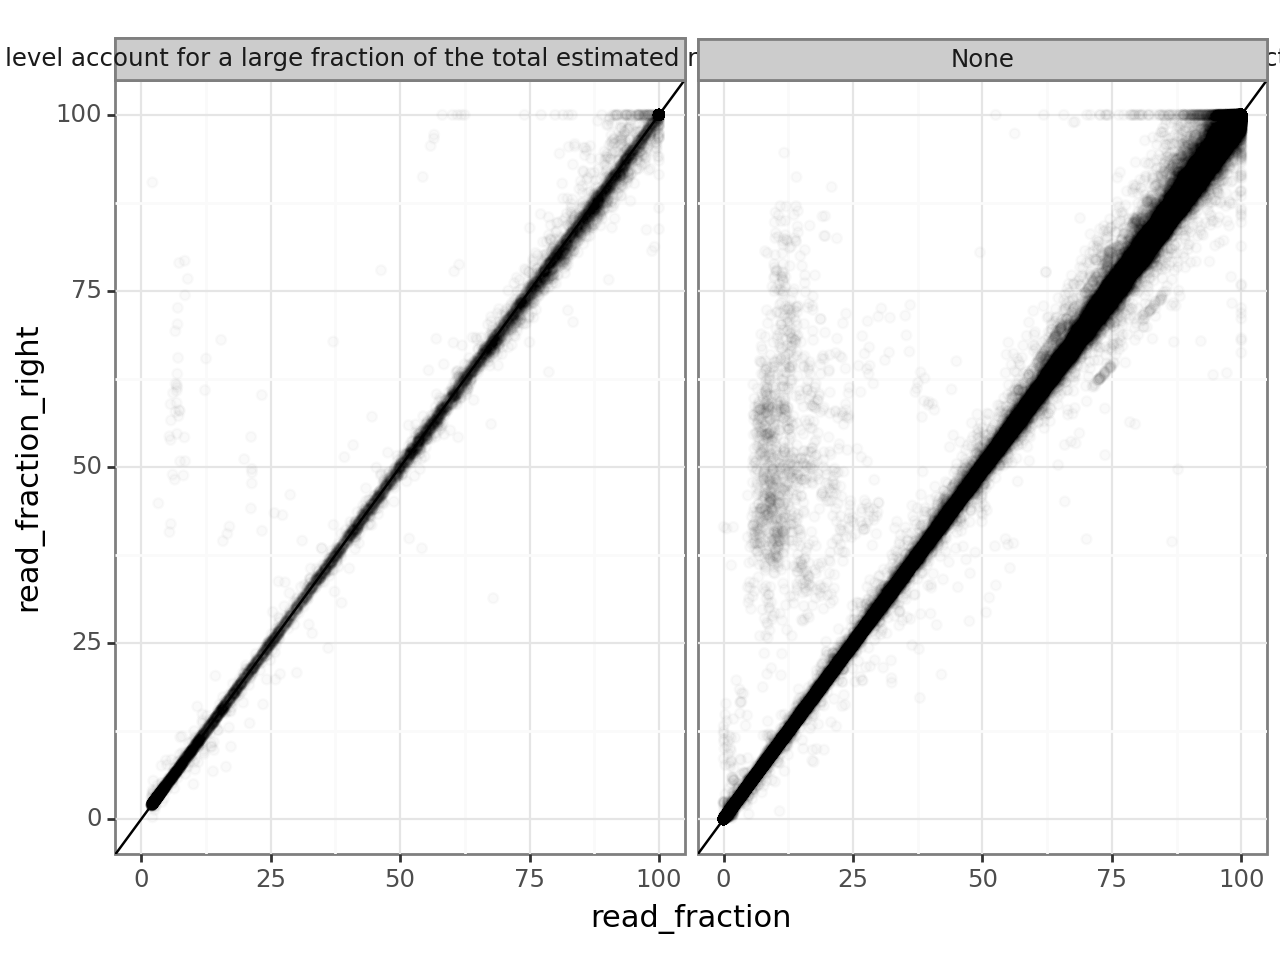

<Figure Size: (640 x 480)>

In [6]:
ggplot(smf, aes(x='read_fraction', y='read_fraction_right')) + geom_point(alpha=0.02) + geom_abline(intercept=0, slope=1) +theme_bw()+facet_wrap('warning')

In [7]:
smf.filter(pl.col('read_fraction')<25).filter(pl.col('read_fraction_right')>50).sample(10)

sample,bacterial_archaeal_bases,metagenome_size,read_fraction,average_bacterial_archaeal_genome_size,warning,bacterial_archaeal_bases_right,metagenome_size_right,read_fraction_right,average_bacterial_archaeal_genome_size_right,warning_right,diff
str,i64,f64,f64,i64,str,i64,f64,f64,i64,str,f64
"""ERR3192199""",320485053,3.1030e9,10.33,3961007,null,1618270846,3.1030e9,52.15,3262182,null,-41.82
"""ERR3191433""",86474701,8.86e8,9.76,3340081,null,698313514,8.86e8,78.82,3145840,null,-69.06
"""ERR3191719""",149116838,8.23e8,18.12,4171100,null,417763349,8.23e8,50.76,3438664,null,-32.64
"""ERR3191713""",89286430,6.8e8,13.13,3794578,null,460752219,6.8e8,67.76,3255739,null,-54.63
"""ERR3191826""",91430205,4.7e8,19.45,3925728,null,307191726,4.7e8,65.36,3299943,null,-45.91
"""ERR3191073""",57056899,5.29e8,10.79,3793677,null,270506191,5.29e8,51.14,3236494,null,-40.35
"""ERR3191311""",107890820,5.6e8,19.27,3804331,null,325442532,5.6e8,58.11,3292953,null,-38.84
"""ERR3191015""",239568454,1.3920e9,17.21,4105011,null,771865068,1.3920e9,55.45,3360172,null,-38.24
"""ERR3190962""",43107441,4.44e8,9.71,3504670,null,243320257,4.44e8,54.8,3168645,null,-45.09
